In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("NACC_visitation_data.zip")

df.head()

/var/folders/96/qt18jlz919xc0br2xcsq_khm0000gp/T/ipykernel_17284/920167828.py:5: DtypeWarning: Columns (0: HISPORX, 1: RACEX, 2: RACESECX, 3: RACETERX, 4: PRIMLANX, 5: INHISPOX, 6: INRACEX, 7: INRASECX, 8: INRATERX, 9: INRELTOX, 10: NACCAMX, 11: NACCAMSX, 12: NACCFMX, 13: NACCFMSX, 14: NACCOMX, 15: NACCOMSX, 16: DRUG16, 17: DRUG17, 18: DRUG18, 19: DRUG19, 20: DRUG20, 21: DRUG21, 22: DRUG22, 23: DRUG23, 24: DRUG24, 25: DRUG25, 26: DRUG26, 27: DRUG27, 28: DRUG28, 29: DRUG29, 30: DRUG30, 31: DRUG31, 32: DRUG32, 33: DRUG33, 34: DRUG34, 35: DRUG35, 36: DRUG36, 37: DRUG37, 38: DRUG38, 39: DRUG39, 40: DRUG40, 41: CVOTHRX, 42: NCOTHRX, 43: ARTHTYPX, 44: OTHSLEEX, 45: ABUSX, 46: PSYCDISX, 47: CVDIMAGX, 48: SPEECHX, 49: FACEXPX, 50: TRESTFAX, 51: TRESTRHX, 52: TRESTLHX, 53: TRESTRFX, 54: TRESTLFX, 55: TRACTRHX, 56: TRACTLHX, 57: RIGDNEX, 58: RIGDUPRX, 59: RIGDUPLX, 60: RIGDLORX, 61: RIGDLOLX, 62: TAPSRTX, 63: TAPSLFX, 64: HANDMVRX, 65: HANDMVLX, 66: HANDATRX, 67: HANDATLX, 68: LEGRTX, 69: LEGLFX

,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,...,LBOTHMO,LBOTHDY,LBOTHPOS,LBOTHAVL,LBOCGAIT,LBOCGMO,LBOCGYR,LBOCGDY,LBOCGPOS,LBOCGAVL
0,NACC002909,186,I,3.0,12,28,2022,1,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NACC002909,186,F,3.0,1,23,2024,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NACC002909,186,F,3.0,3,5,2025,3,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NACC003142,186,I,3.0,2,11,2025,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NACC003487,186,I,3.0,11,15,2023,1,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
mmse_matrix = df.pivot_table(
    index="NACCID",
    columns="NACCAGE",
    values="NACCMMSE"
)

mmse_matrix.head()

NACCAGE,18,19,20,21,22,23,24,25,26,27,...,101,102,103,104,105,106,107,108,109,110
NACCID,,,,,,,,,,,,,,,,,,,,,
NACC000011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NACC000034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NACC000067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NACC000073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NACC000095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


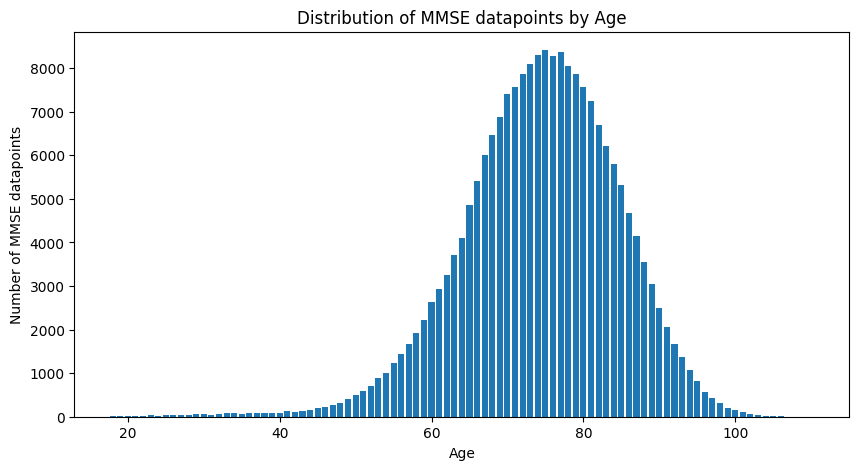

In [3]:
# keep only valid MMSE rows
df_valid = df[["NACCAGE", "NACCMMSE"]].dropna()

# count datapoints per age
age_counts = df_valid.groupby("NACCAGE")["NACCMMSE"].count().sort_index()

# graph
plt.figure(figsize=(10,5))
plt.bar(age_counts.index, age_counts.values)

plt.xlabel("Age")
plt.ylabel("Number of MMSE datapoints")
plt.title("Distribution of MMSE datapoints by Age")

plt.show()

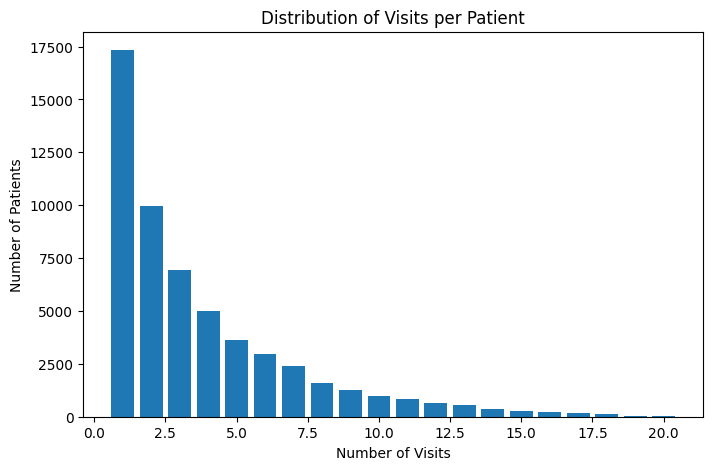

In [4]:
visits_per_person = df.groupby("NACCID").size()

visit_distribution = visits_per_person.value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(visit_distribution.index, visit_distribution.values)

plt.xlabel("Number of Visits")
plt.ylabel("Number of Patients")
plt.title("Distribution of Visits per Patient")

plt.show()

In [5]:
# number of visits per patient
visits_per_person = df.groupby("NACCID").size()

# users with >= X visits
num_users_above_threshold = (visits_per_person >= 10).sum()

num_users_above_threshold

np.int64(4224)

In [7]:
# save collaborative filtering matrix to repo

mmse_matrix.to_csv("mmse_user_age_matrix.csv")